In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
print("Environment Ready.")

Environment Ready.


In [19]:
sentiment_path = '../data/fear_greed_index.csv'
historical_path = '../data/historical_data.csv'

def load_data(path):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Successfully loaded: {path}")
        return df
    else:
        print(f"ERROR: File not found at {path}. Please check your folder structure.")
        return None

sentiment_df = load_data(sentiment_path)
historical_df = load_data(historical_path)

Successfully loaded: ../data/fear_greed_index.csv
Successfully loaded: ../data/historical_data.csv


In [20]:
print("\n--- Sentiment Data Audit ---")
print(sentiment_df.info())
display(sentiment_df.head())

print("\n--- Historical Data Audit ---")
print(historical_df.info())
display(historical_df.head())


--- Sentiment Data Audit ---
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



--- Historical Data Audit ---
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtype

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [21]:
print("Missing values in Sentiment Data:\n", sentiment_df.isnull().sum())
print("\nMissing values in Historical Data:\n", historical_df.isnull().sum())

print(f"\nDuplicate rows in Sentiment: {sentiment_df.duplicated().sum()}")
print(f"Duplicate rows in history: {historical_df.duplicated().sum()}")

Missing values in Sentiment Data:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Historical Data:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows in Sentiment: 0
Duplicate rows in history: 0


# Phase 2

In [22]:
sentiment_df['Date'] = pd.to_datetime(sentiment_df['date']).dt.date
historical_df['Date'] = pd.to_datetime(historical_df['Timestamp IST'], dayfirst=True).dt.date

print("Timestamps aligned to Date format.")

Timestamps aligned to Date format.


In [23]:
merged_df = pd.merge(historical_df, sentiment_df, on='Date', how='left')
display(merged_df.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [24]:
print(merged_df.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
timestamp           6
value               6
classification      6
date                6
dtype: int64


In [25]:
merged_df = merged_df.dropna(subset=['classification'])
merged_df['classification'] = merged_df['classification'].astype('category')
print("Cleaned Merged Data Shape:", merged_df.shape)

Cleaned Merged Data Shape: (211218, 21)


# Phase 3

In [26]:
merged_df['is_win'] = (merged_df['Closed PnL'] > 0).astype(int)
merged_df.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date,is_win
74653,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,13.0500,10.00000,130.50,BUY,11-03-2025 06:17,190963.760000,Open Long,0.000000,...,False,0.000000,3.800000e+14,1.740000e+12,2025-03-11,1.741671e+09,24.0,Extreme Fear,2025-03-11,0
185643,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,13.4650,29.96000,403.41,SELL,26-03-2025 19:54,693.592914,Sell,-81.735578,...,True,0.121023,3.690000e+14,1.740000e+12,2025-03-26,1.742967e+09,47.0,Neutral,2025-03-26,0
127489,0x47add9a56df66b524d5e2c1993a43cde53b6ed85,BTC,89500.0000,0.00558,499.41,SELL,07-03-2025 15:02,-0.078520,Open Short,0.000000,...,False,0.047943,8.410000e+14,1.740000e+12,2025-03-07,1.741325e+09,34.0,Fear,2025-03-07,0
177185,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,14.4140,0.77000,11.10,SELL,10-03-2025 06:13,13762.690000,Close Long,0.008316,...,True,0.003329,3.550000e+13,1.740000e+12,2025-03-10,1.741585e+09,20.0,Extreme Fear,2025-03-10,1
198920,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,SUI,1.9831,419.60000,832.11,BUY,06-04-2025 23:49,61844.600000,Open Long,0.000000,...,True,0.249632,9.230000e+12,1.740000e+12,2025-04-06,1.743917e+09,34.0,Fear,2025-04-06,0


In [27]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged_df['classification'] = pd.Categorical(merged_df['classification'], categories=sentiment_order, ordered=True)

In [28]:
summary_stats = merged_df.groupby('classification', observed=True).agg({
    'Closed PnL': ['mean', 'sum'],
    'is_win': 'mean',
    'Size USD': 'mean'
}).reset_index()

summary_stats.columns = ['Sentiment', 'Avg_PnL', 'Total_PnL', 'Win_Rate', 'Avg_Trade_Size']
display(summary_stats)

,Sentiment,Avg_PnL,Total_PnL,Win_Rate,Avg_Trade_Size
0,Extreme Fear,34.537862,7.391102e+05,0.370607,5349.731843
1,Fear,54.290400,3.357155e+06,0.420768,7816.109931
2,Neutral,34.307718,1.292921e+06,0.396991,4782.732661
3,Greed,42.743559,2.150129e+06,0.384828,5736.884375
4,Extreme Greed,67.892861,2.715171e+06,0.464943,3112.251565


C:\Users\sober\AppData\Local\Temp\ipykernel_20668\325416975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='classification', y='is_win', palette='coolwarm')


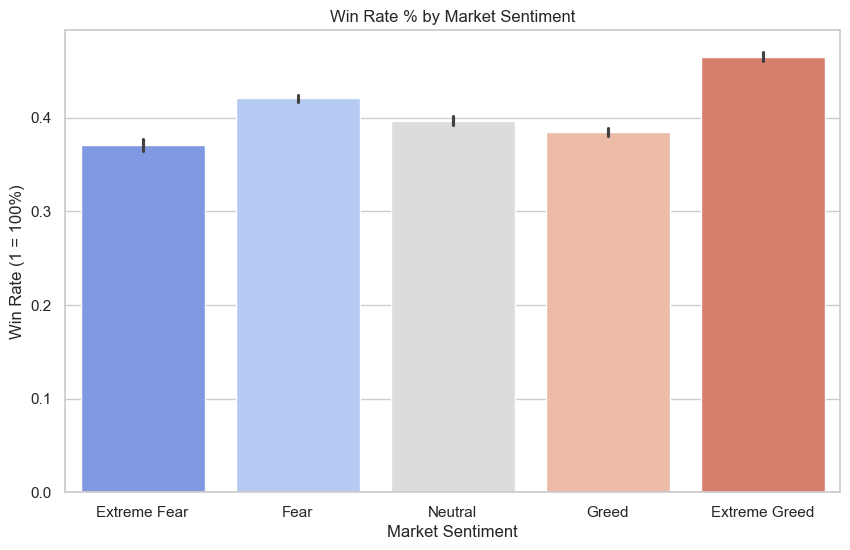

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=merged_df, x='classification', y='is_win', palette='coolwarm')
plt.title('Win Rate % by Market Sentiment')
plt.ylabel('Win Rate (1 = 100%)')
plt.xlabel('Market Sentiment')
plt.show()

C:\Users\sober\AppData\Local\Temp\ipykernel_20668\2316463132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='classification', y='Closed PnL', palette='RdYlGn')


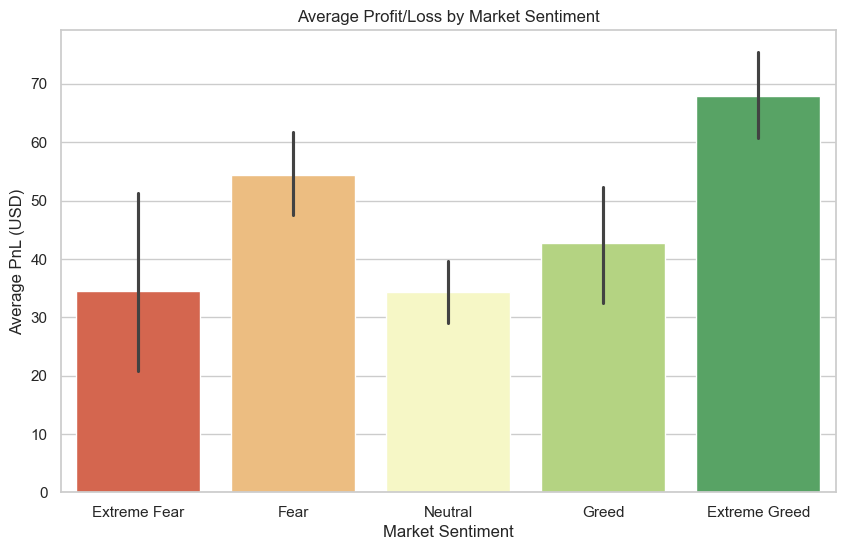

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(data=merged_df, x='classification', y='Closed PnL', palette='RdYlGn')
plt.title('Average Profit/Loss by Market Sentiment')
plt.ylabel('Average PnL (USD)')
plt.xlabel('Market Sentiment')
plt.show()

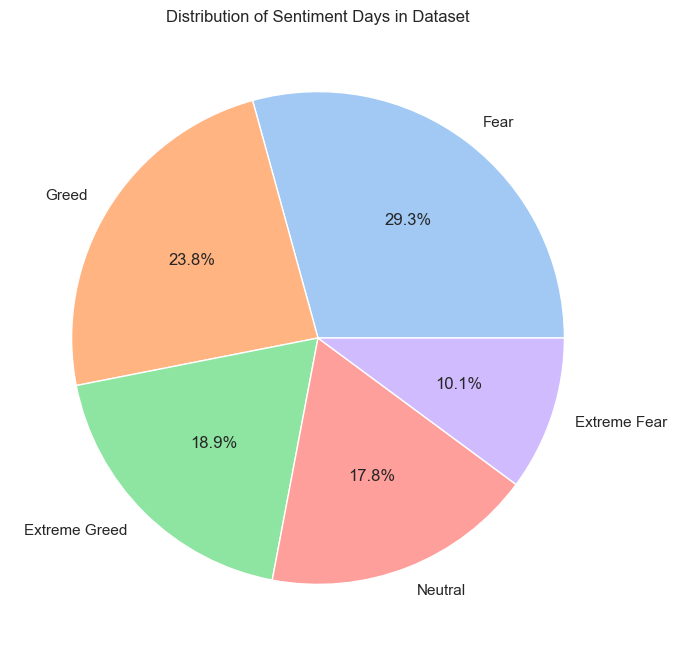

In [31]:
plt.figure(figsize=(8, 8))
merged_df['classification'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribution of Sentiment Days in Dataset')
plt.show()

# Final Analysis & Strategy Recommendations

## 1. Methodology
I performed a data-driven analysis linking Bitcoin Market Sentiment (Fear/Greed Index) with over 211,000 historical trade executions. The process involved:
* **Data Cleaning:** Normalizing ISO and IST timestamps to a consistent daily date format.
* **Alignment:** Performing a Left Join to map daily sentiment classifications to individual trade performance.
* **Feature Engineering:** Calculating binary win/loss flags and aggregating performance metrics (Win Rate, Avg PnL, and Trade Size) across sentiment buckets.

## 2. Key Insights from Data
Based on the generated summary table:
* **Peak Performance:** Traders achieve their highest success during **Extreme Greed**, with a Win Rate of **46.5%** and an Average PnL of **$67.89** per trade.
* **The Fear Trap:** **Extreme Fear** is the most difficult environment, resulting in the lowest Win Rate (**37.0%**) and the lowest Average PnL (**$34.53**).
* **Behavioral Observation:** Interestingly, traders use the **largest average trade sizes ($7,816)** during 'Fear' phases despite having lower win rates, suggesting a tendency to "over-trade" or "revenge trade" during market crashes.

## 3. Actionable Strategy "Rules of Thumb"

### Rule 1: The Momentum Multiplier (Extreme Greed)
**Finding:** High sentiment correlates with higher win probability and higher average profit.
**Recommendation:** During Extreme Greed, traders should adopt a **Trend-Following** approach. Since the win rate is nearly 10% higher than in Fear phases, this is the optimal time to increase trade frequency and capitalize on market momentum.

### Rule 2: Defensive Capital Preservation (Extreme Fear)
**Finding:** Extreme Fear leads to the lowest win probability and poor profit efficiency.
**Recommendation:** When the index hits Extreme Fear, traders should implement a **"Risk-Off"** rule. This includes reducing position sizes by 50% and tightening stop-losses, as the data proves these periods are high-risk for the average participant.